# Estimating the Dynamical Mass of a Galaxy Cluster Using SDSS Spectroscopic Data

### Objective
The main objective of this project is to estimate the **dynamical mass** of a galaxy cluster using spectroscopic redshift and photometric data drawn from the Sloan Digital Sky Survey (SDSS DR16) archive, and to test this estimate against the cluster's **luminous (stellar) mass**. In particular, this analysis aims to: (1) identify which galaxies in a field are genuine cluster members using a 3 $ \sigma $ redshift-clipping criterion, (2) determine the systemic cluster redshift and the characteristic velocity dispersion of member galaxies via the relativistic Doppler formula, (3) estimate the physical size (diameter) of the cluster from its angular extent and angular diameter distance, (4) apply the virial theorem to compute the cluster's dynamical mass, (5) compute the cluster's luminous mass using an empirical stellar mass-to-light relation calibrated on SDSS colors (Bell et al. 2003), and (6) compare the dynamical and luminous mass estimates to assess whether the cluster's gravitational potential is dominated by unseen (dark) matter.

### Dataset Description
This project uses spectroscopic and photometric data queried from the **SDSS DR16 Skyserver SQL search tool** (`http://skyserver.sdss.org/dr16/en/tools/search/sql.aspx`). The query retrieves photometric objects classified as galaxies (`type = 3`) within a **10 arcminute** search radius of a field centered at (RA, Dec) = (258.1294°, 64.0926°), restricted to spectroscopic redshifts in the range $0.05 < z < 0.20$:

```sql
SELECT
s.objid, sz.ra as ra, sz.dec as dec, pz.z as photoz, pz.zerr as photozerr,
sz.z as specz, sz.zerr as speczerr, b.distance as proj_sep,
s.modelMag_u as umag, s.modelMagErr_u as umagerr,
s.modelMag_g as gmag, s.modelMagErr_g as gmagerr,
s.modelMag_r as rmag, s.modelMagerr_r as rmagerr, s.type as obj_type

FROM BESTDR16..PhotoObjAll as s
JOIN dbo.fGetNearbyObjEq(258.1294,64.0926,10.0) AS b ON b.objID = S.objID
JOIN Photoz as pz ON pz.objid = s.objid
JOIN specObjAll as sz ON sz.bestobjid = s.objid

WHERE s.type=3 and sz.z > 0.05 and sz.z < 0.20
```

The query result is exported and used here as the file `Skyserver_SQL6_original.xlsx`. We specifically use the following columns from the dataset:
- `objid` : Unique identifier for each photometric object (used to average repeated observations)
- `specz` : Spectroscopic redshift of the galaxy
- `ra`, `dec` : Right ascension and declination (degrees)
- `proj_sep` : Projected angular separation from the field center (arcmin)
- `gmag`, `rmag` : SDSS model magnitudes in the g (green) and r (red) bands, used to estimate stellar mass

### Data Cleaning & Preprocessing

#### Libraries Calling:

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from astropy.constants import G, c
from astropy.cosmology import Planck18 as cosmo
import astropy.units as u

#### Defining Physical Constants
Before we begin calculations, we define the key physical constants used throughout this analysis:
- $H_0$ : Hubble constant, describing the present-day expansion rate of the Universe (taken from the Planck18 cosmology).
- $c$ : Speed of light.
- $G$ : Gravitational constant.
- $q_0$ : Deceleration parameter, used in the low-redshift Taylor expansion for co-moving distance.

We use `astropy.constants` and `astropy.units` throughout to keep unit conversions consistent and explicit.

In [2]:
# Constants:
H_0 = cosmo.H0.to(1 / u.s)  # Hubble constant in SI units (1/s)
c = c.to(u.m / u.s)  # Speed of light in m/s
G = G.to(u.m**3 * u.kg**(-1) * u.s**(-2))  # Gravitational constant in SI units (m^3 kg^-1 s^-2)
q0 = -0.534  # Deceleration parameter (assumed from Planck fit, KEEP as it is)

print("H0 =", H_0, "\nc =", c, "\nG =", G, "\nq0 =", q0)

H0 = 2.192711267238057e-18 1 / s 
c = 299792458.0 m / s 
G = 6.6743e-11 m3 / (kg s2) 
q0 = -0.534


#### Load the SDSS Dataset

In [3]:
# Local file path -- update this to point to your downloaded SDSS query output
file_path = r"D:\Physics\python\India Space Academy\projects\Dynamical Mass\Skyserver_SQL6_original - Copy_2.xlsx"
# Load the file
file = pd.read_excel(file_path)

# See structure
file.info()  # Display the structure of the DataFrame
print("**************************************************")
print(file.columns)  # Print the column names to understand the structure
print("**************************************************")
file.head()  # Preview the first few rows of the DataFrame

<class 'pandas.DataFrame'>
RangeIndex: 139 entries, 0 to 138
Data columns (total 15 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   objid      139 non-null    int64  
 1   ra         139 non-null    float64
 2   dec        139 non-null    float64
 3   photoz     139 non-null    float64
 4   photozerr  139 non-null    float64
 5   specz      139 non-null    float64
 6   speczerr   139 non-null    float64
 7   proj_sep   139 non-null    float64
 8   umag       139 non-null    float64
 9   umagerr    139 non-null    float64
 10  gmag       139 non-null    float64
 11  gmagerr    139 non-null    float64
 12  rmag       139 non-null    float64
 13  rmagerr    139 non-null    float64
 14  obj_type   139 non-null    int64  
dtypes: float64(13), int64(2)
memory usage: 16.4 KB
**************************************************
Index(['objid', 'ra', 'dec', 'photoz', 'photozerr', 'specz', 'speczerr',
       'proj_sep', 'umag', 'umagerr', 'gmag', 'gma

,objid,ra,dec,photoz,photozerr,specz,speczerr,proj_sep,umag,umagerr,gmag,gmagerr,rmag,rmagerr,obj_type
0,1237671768542469888,257.82458,64.133257,0.079193,0.022867,0.082447,0.000017,8.347733,18.96488,0.043377,17.49815,0.005672,16.75003,0.004708,3
1,1237671768542469888,257.82458,64.133257,0.079193,0.022867,0.082466,0.000014,8.347733,18.96488,0.043377,17.49815,0.005672,16.75003,0.004708,3
2,1237671768542469888,257.83332,64.126043,0.091507,0.014511,0.081218,0.000021,8.011259,20.22848,0.072019,18.38334,0.007763,17.46793,0.005828,3
3,1237671768542540032,257.85137,64.173247,0.081102,0.009898,0.079561,0.000022,8.739276,19.21829,0.050135,17.18970,0.004936,16.22043,0.003769,3
4,1237671768542540032,257.85137,64.173247,0.081102,0.009898,0.079568,0.000019,8.739276,19.21829,0.050135,17.18970,0.004936,16.22043,0.003769,3


#### Averaging Repeated Observations per Object
Astronomical catalogs often contain multiple entries for the same object (identified by a unique `objid`), due to repeated spectroscopic observations. To reduce this to a single row per object, we aggregate the data using the mean `specz` for each object, keeping a single `ra`, `dec`, and `proj_sep` value per object, and averaging the photometric magnitudes.

In [4]:
# Calculating the average specz (and other columns) for each objid:
averaged_file = file.groupby('objid').agg({
    'specz': 'mean',       # Mean of all spec-z values for that object
    'ra': 'first',         # RA is essentially constant for a given object
    'dec': 'first',        # Dec is essentially constant for a given object
    'proj_sep': 'first',   # Projected separation from field center
    'rmag': 'mean',        # Mean r-band magnitude
    'gmag': 'mean'         # Mean g-band magnitude
}).reset_index()

averaged_file.describe()['specz']

count    6.000000
mean     0.080576
std      0.001905
min      0.077730
25%      0.079580
50%      0.080638
75%      0.081886
max      0.082918
Name: specz, dtype: float64

#### Cleaning and Extracting Relevant Data

In [5]:
# Drop rows with missing values in any of the columns we need
clean_avg_file = averaged_file.dropna(subset=['specz', 'ra', 'dec', 'proj_sep', 'rmag', 'gmag'])

# Extract the cleaned columns as pandas Series for convenience
clean_specz = clean_avg_file['specz']       # Cleaned spectroscopic redshift
clean_ra = clean_avg_file['ra']             # Cleaned RA
clean_dec = clean_avg_file['dec']           # Cleaned Dec
clean_proj_sep = clean_avg_file['proj_sep'] # Cleaned projected separation

print("Number of NaNs remaining in specz:", clean_avg_file['specz'].isna().sum())
print("Cleaned specz data:\n", clean_specz)

Number of NaNs remaining in specz: 0
Cleaned specz data:
 0    0.082044
1    0.079863
2    0.081413
3    0.077730
4    0.082918
5    0.079486
Name: specz, dtype: float64


### Exploratory Data Analysis (EDA)

#### Redshift Distribution
Let's visualize how the spectroscopic redshifts of the galaxies in this field are distributed. Since a genuine cluster is a group of galaxies that are gravitationally bound and therefore share a similar systemic redshift, this distribution should show a concentration of objects around the cluster's redshift, with field/background galaxies scattered more broadly.

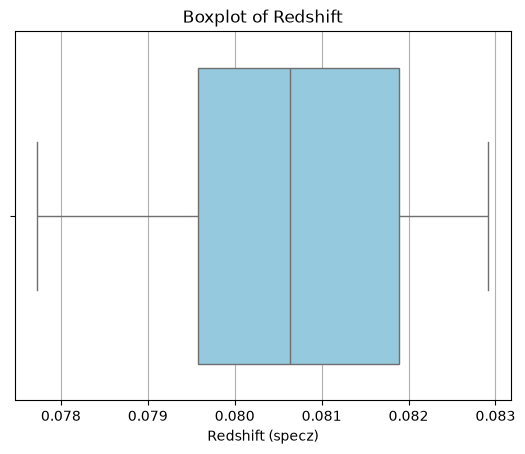

In [7]:
# Boxplot of the redshift distribution
plt.figure(num="Distribution_of_Redshift_Boxplot")
plt.title("Boxplot of Redshift")
sns.boxplot(x=clean_specz.values, color='skyblue')
plt.xlabel('Redshift (specz)')
plt.grid(True, axis='x')
plt.show()

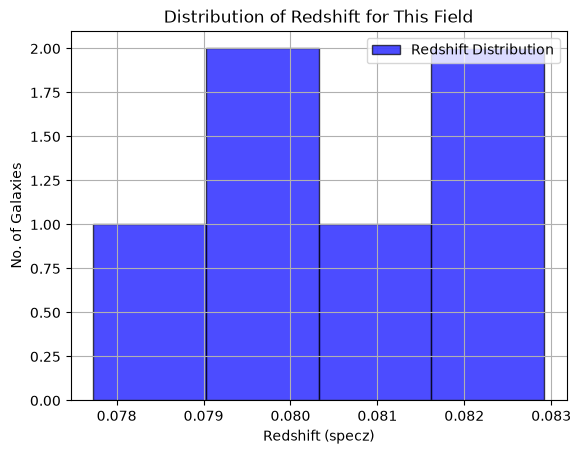

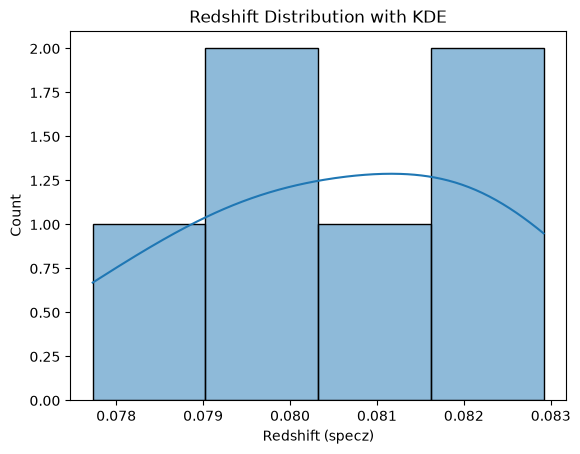

In [8]:
# Histogram of the redshift distribution
Bin = int(np.ceil(1 + np.log2(len(clean_specz))))  # Sturges's rule, n: no. of data points

plt.figure()
plt.title("Distribution of Redshift for This Field")
plt.hist(clean_specz.values, bins=Bin, color='blue', alpha=0.7, edgecolor='black', label='Redshift Distribution')
plt.xlabel('Redshift (specz)')
plt.ylabel('No. of Galaxies')
plt.grid(True)
plt.legend()
plt.show()

# Same distribution with a KDE overlay for a smoother view
plt.figure()
sns.histplot(clean_specz.values, kde=True, bins=Bin)
plt.title("Redshift Distribution with KDE")
plt.xlabel('Redshift (specz)')
plt.show()

#### Identifying Cluster Members (3 $\sigma$ Redshift Clipping)
To separate genuine cluster members from unrelated foreground/background galaxies, we use a $3\sigma$ criterion: most astronomers treat objects whose redshift lies beyond $3\sigma$ of the mean redshift as unlikely to belong to the same bound group. We compute the mean and standard deviation of the redshift distribution and use these to define the cluster membership limits.

In [9]:
mean_specz = clean_specz.mean()  # Mean of specz
std_specz = clean_specz.std()    # Standard deviation of specz
print("Mean of specz:", mean_specz, "\nStandard deviation of specz:", std_specz)

# 3-sigma limits
lower_limit = mean_specz - 3 * std_specz
upper_limit = mean_specz + 3 * std_specz
three_sigma_limits = [lower_limit, upper_limit]
print("3\u03C3 limits:", three_sigma_limits, "*****OR*****", lower_limit, 'to', upper_limit)

Mean of specz: 0.08057561087771982 
Standard deviation of specz: 0.00190455549968548
3σ limits: [np.float64(0.07486194437866338), np.float64(0.08628927737677626)] *****OR***** 0.07486194437866338 to 0.08628927737677626


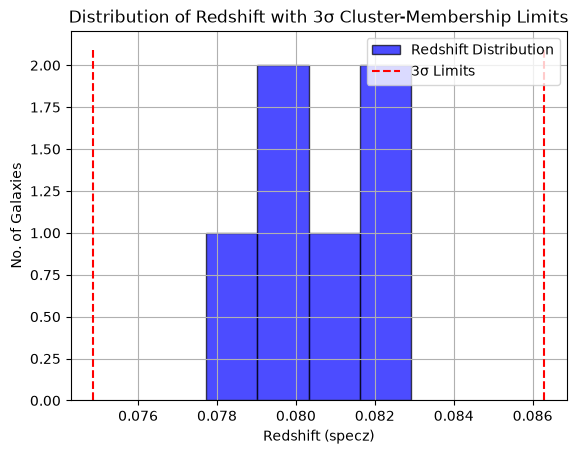

In [10]:
# Re-plot the histogram with the 3-sigma limits marked
plt.figure()
plt.title("Distribution of Redshift with 3\u03c3 Cluster-Membership Limits")
plt.hist(clean_specz.values, bins=Bin, color='blue', alpha=0.7, edgecolor='black', label='Redshift Distribution')
plt.vlines(three_sigma_limits, 0, plt.ylim()[1], colors='red', linestyles='dashed', label='3\u03c3 Limits')
plt.xlabel('Redshift (specz)')
plt.ylabel('No. of Galaxies')
plt.grid(True)
plt.legend()
plt.show()

In [11]:
# Filter the data: keep only galaxies within the 3-sigma limit -- these form the cluster
three_sigma_file = clean_avg_file[clean_avg_file['specz'].between(lower_limit, upper_limit)].copy()
print("Number of galaxies identified as cluster members:", len(three_sigma_file))
print(three_sigma_file)

Number of galaxies identified as cluster members: 6
                 objid     specz         ra        dec  proj_sep       rmag  \
0  1237671768542469888  0.082044  257.82458  64.133257  8.347733  16.989330   
1  1237671768542540032  0.079863  257.85137  64.173247  8.739276  16.924034   
2  1237671768542599936  0.081413  258.25996  64.169255  5.730846  16.775837   
3  1237671939804489984  0.077730  257.78072  64.082540  9.162669  16.781039   
4  1237671939804559872  0.082918  258.02787  64.040384  4.113855  16.752333   
5  1237671939804620032  0.079486  258.31944  64.055688  5.454981  16.686556   

        gmag  
0  17.793213  
1  17.676717  
2  17.606491  
3  17.688868  
4  17.645848  
5  17.529027  


### Modeling & Analysis

#### Determining the Cluster Redshift and Velocity Dispersion
The redshifts (`specz`) in `three_sigma_file` are already restricted to within the $3\sigma$ limit, so these galaxies are treated as forming a single bound cluster clustered around the mean redshift. We first take the mean of these redshifts as the **systemic cluster redshift**.

The **relative velocity** of each galaxy with respect to the cluster mean redshift is then computed using the relativistic Doppler formula:

$$
v = c \cdot \frac{(1 + z)^2 - (1 + z_{\text{cluster}})^2}{(1 + z)^2 + (1 + z_{\text{cluster}})^2}
$$

where:
- $v$ is the relative velocity,
- $z$ is the redshift of the individual galaxy,
- $z_{\text{cluster}}$ is the mean cluster redshift,
- $c$ is the speed of light.

The standard deviation of these relative velocities gives the **velocity dispersion**, the characteristic scale of random (peculiar) motions of galaxies within the cluster, which enters directly into the virial mass estimate below.

In [12]:
cluster_redshift = three_sigma_file['specz'].mean()  # Mean redshift of the cluster
print("Cluster Redshift (Mean of specz):", cluster_redshift)

# Relative velocity of each galaxy with respect to the cluster, using the relativistic Doppler formula:
def relative_velocity(z, z_cluster):
    '''
    Calculate the relative velocity using the relativistic Doppler formula.

    Parameters:
    z (float): Redshift of the galaxy.
    z_cluster (float): Redshift of the cluster.

    Returns:
    float: Relative velocity in m/s.
    '''
    return c.value * (((1 + z)**2 - (1 + z_cluster)**2) / ((1 + z)**2 + (1 + z_cluster)**2))  # in m/s

three_sigma_file['rel_velocity'] = relative_velocity(three_sigma_file['specz'], cluster_redshift)
three_sigma_file['rel_velocity'].describe()

Cluster Redshift (Mean of specz): 0.08057561087771982


count         6.000000
mean       -388.047913
std      528504.937052
min     -790585.512930
25%     -276279.918287
50%       17262.047081
75%      363388.386029
max      649096.539018
Name: rel_velocity, dtype: float64

In [13]:
# Characteristic value of relative velocity (velocity dispersion) of the cluster along the line of sight:
disp_ms = three_sigma_file['rel_velocity'].std()  # Standard deviation of relative velocity in m/s
disp = disp_ms / 1000  # Convert from m/s to km/s

print(f"The value of the cluster redshift = {cluster_redshift:.4}")
print(f"The characteristic velocity dispersion of the cluster along the line of sight = {disp:.4} km/s")

The value of the cluster redshift = 0.08058
The characteristic velocity dispersion of the cluster along the line of sight = 528.5 km/s


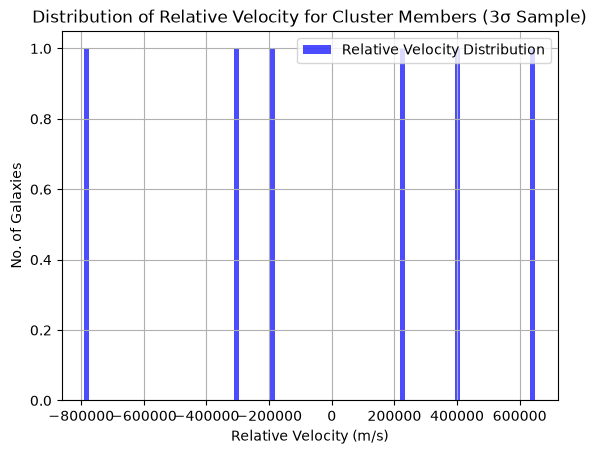

In [14]:
# Histogram of the relative velocity distribution of cluster members
plt.figure()
plt.title("Distribution of Relative Velocity for Cluster Members (3\u03c3 Sample)")
plt.hist(three_sigma_file['rel_velocity'], bins=90, color='blue', alpha=0.7, label='Relative Velocity Distribution')
plt.xlabel('Relative Velocity (m/s)')
plt.ylabel('No. of Galaxies')
plt.grid(True)
plt.legend()
plt.show()

#### Estimating the Physical Size of the Cluster
To convert the *angular* extent of the cluster into a *physical* size, we first look at how member galaxies are spatially distributed on the sky, using the projected separation from the field center.


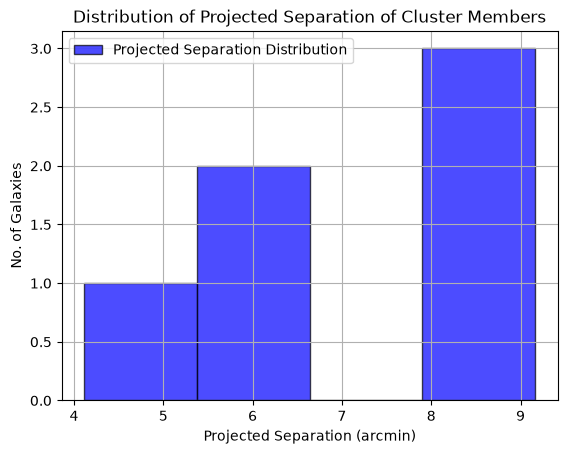

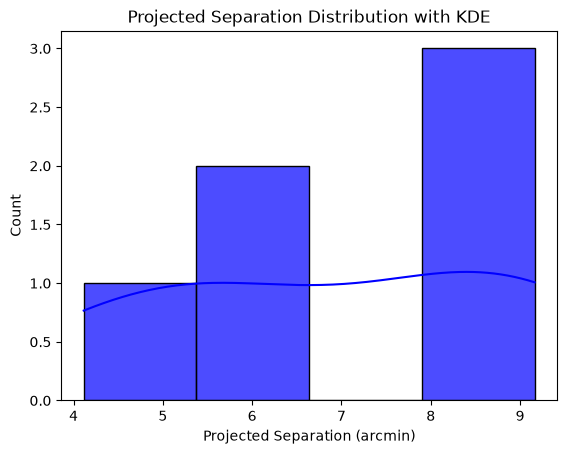

In [15]:
three_proj_sep = three_sigma_file['proj_sep']  # Projected separation of cluster members from field center

Bin2 = int(np.ceil(1 + np.log2(len(three_proj_sep))))  # Sturges's rule

plt.figure()
plt.title("Distribution of Projected Separation of Cluster Members")
plt.hist(three_proj_sep.values, bins=Bin2, color='blue', alpha=0.7, edgecolor='black', label='Projected Separation Distribution')
plt.xlabel('Projected Separation (arcmin)')
plt.ylabel('No. of Galaxies')
plt.grid(True)
plt.legend()
plt.show()

# KDE view of the same distribution
plt.figure()
sns.histplot(three_proj_sep.values, kde=True, bins=Bin2, color='blue', alpha=0.7, edgecolor='black')
plt.title("Projected Separation Distribution with KDE")
plt.xlabel('Projected Separation (arcmin)')
plt.show()

We now estimate the **physical diameter** of the galaxy cluster using cosmological distance measures appropriate for low redshift:

- The **co-moving distance** $r$, approximated using a Taylor expansion valid at low $z$:
$$
r = \frac{cz}{H_0}\left(1 - \frac{z}{2}(1 + q_0)\right)
$$
where $q_0$ is the deceleration parameter.

- The **angular diameter distance** $D_A$:
$$
D_A = \frac{r}{1+z}
$$

- The physical **diameter** of the cluster, taking twice the maximum projected separation as the full angular extent $\theta$ (converted from arcminutes to radians):
$$
\text{diameter} = D_A \cdot \theta
$$

This gives a rough estimate of the cluster's size in megaparsecs (Mpc), assuming a flat $\Lambda$ CDM cosmology and treating the cluster as roughly spherical.

In [17]:
# We have already calculated cluster_redshift and disp_ms above.
# H_0 is in 1/s, c is in m/s.

# Co-moving distance (r) of the cluster:
r = ((c * cluster_redshift) / H_0) * (1 - (cluster_redshift / 2) * (1 + q0))  # in m

# Angular diameter distance (D_A):
D_A = r / (1 + cluster_redshift)  # in m
D_A_Mpc = D_A.to(u.Mpc)  # Convert to Mpc

# Diameter of the cluster: take 2 * max projected separation as the full angular size, convert arcmin -> radian
theta_arcmin = 2 * three_proj_sep.max()
theta_rad = theta_arcmin * (np.pi / (180 * 60))  # arcmin to radians

diameter = D_A_Mpc * theta_rad  # Diameter in Mpc

print("Co-moving distance (r):", r.to(u.Mpc))
print("Angular diameter distance (D_A):", D_A_Mpc)
print("Diameter of the cluster:", diameter)

Co-moving distance (r): 350.31707957814143 Mpc
Angular diameter distance (D_A): 324.1948791474103 Mpc
Diameter of the cluster: 1.7281612008648644 Mpc


#### Calculating the Dynamical Mass of the Cluster (Virial Theorem)
We now estimate the **dynamical mass** of the galaxy cluster using the virial theorem:

$$
M_{\text{dyn}} = \frac{3\sigma^2 R}{G}
$$

Where:
- $\sigma$ is the **velocity dispersion** in m/s,
- $R$ is the **cluster radius** in meters (half the physical diameter),
- $G$ is the **gravitational constant** in SI units,
- The factor of 3 accounts for converting the observed line-of-sight (1D) velocity dispersion into a 3D isotropic velocity dispersion.

This mass estimate assumes the cluster is in dynamical (virial) equilibrium and gravitationally bound.

In [18]:
# Calculating the dynamical mass in solar masses:
cluster_radius = (diameter / 2).to(u.m)  # Radius of the cluster in meters

mass_dyn = (3 * (disp_ms * (u.m / u.s))**2 * cluster_radius) / G  # Dynamical mass in kg
mass_dyn_solar = mass_dyn.to(u.M_sun)  # Convert to solar masses

print(f"Dynamical Mass of the cluster is {mass_dyn_solar.value:.2e} solar masses")

Dynamical Mass of the cluster is 1.68e+14 solar masses


#### Calculating the Luminous Mass of the Cluster (Bell et al. 2003)
To assess whether the dynamical mass is consistent with the visible matter alone, we independently estimate the cluster's **luminous (stellar) mass** from its photometry. This requires converting each galaxy's apparent magnitude and color into a stellar mass, using the empirical color-dependent mass-to-light relation of Bell et al. (2003):

$$
\log_{10}\left(\frac{M_*}{L_r}\right) = -0.306 + 1.097\,(g - r)
\quad\Longrightarrow\quad
M_* = L_r \times 10^{\,-0.306 + 1.097\,(g-r)}
$$

where $L_r$ is the galaxy's red-band luminosity (in solar units) and $(g-r)$ is its SDSS color (`gmag` $-$ `rmag`). We build up to $L_r$ in steps: co-moving distance $\rightarrow$ angular diameter distance $\rightarrow$ luminosity distance $\rightarrow$ absolute magnitude $\rightarrow$ luminosity, then sum $M_*$ over all cluster members to obtain the total luminous mass.

In [19]:
# g - r band color:
def gr_band_dif(green_mag, red_mag):
    '''
    Calculate the difference between the g and r band magnitudes (galaxy color).

    Parameters:
    green_mag (float): g-band magnitude.
    red_mag (float): r-band magnitude.

    Returns:
    float: g - r color.
    '''
    return green_mag - red_mag

three_sigma_file['g_r'] = gr_band_dif(three_sigma_file['gmag'], three_sigma_file['rmag'])

# Co-moving distance of an individual galaxy:
def r_galaxy(z):
    '''
    Calculate the co-moving distance of a galaxy using its redshift (low-z Taylor expansion).

    Parameters:
    z (float): Redshift of the galaxy.

    Returns:
    float: Co-moving distance in meters.
    '''
    return ((c.value * z) / H_0.value) * (1 - (z / 2) * (1 + q0))  # in m

three_sigma_file['r_g'] = r_galaxy(three_sigma_file['specz'])

# Angular diameter distance of an individual galaxy:
def D_A_galaxy(rg, z):
    '''
    Calculate the angular diameter distance of a galaxy.

    Parameters:
    rg (float): Co-moving distance of the galaxy (m).
    z (float): Redshift of the galaxy.

    Returns:
    float: Angular diameter distance in meters.
    '''
    return rg / (1 + z)

three_sigma_file['D_A_g'] = D_A_galaxy(three_sigma_file['r_g'], three_sigma_file['specz'])

# Luminosity distance of an individual galaxy (returned in parsecs):
def D_L_galaxy(DAg, z):
    '''
    Calculate the luminosity distance of a galaxy.

    Parameters:
    DAg (float): Angular diameter distance of the galaxy (m).
    z (float): Redshift of the galaxy.

    Returns:
    float: Luminosity distance in parsecs.
    '''
    DAG = DAg * (1 + z)**2  # Luminosity distance in meters
    return DAG * (1 / (3.0857e16))  # Convert meters to parsecs

three_sigma_file['D_L_g'] = D_L_galaxy(three_sigma_file['D_A_g'], three_sigma_file['specz'])

# Absolute magnitude in the r band:
def M_r_galaxy(rmag1, D_Lg):
    '''
    Calculate the absolute magnitude in the r band of a galaxy.

    Parameters:
    rmag1 (float): Apparent r-band magnitude.
    D_Lg (float): Luminosity distance in parsecs.

    Returns:
    float: Absolute r-band magnitude.
    '''
    return rmag1 - 5 * np.log10(D_Lg / 10)

three_sigma_file['M_r'] = M_r_galaxy(three_sigma_file['rmag'], three_sigma_file['D_L_g'])

# Red-band luminosity (solar units), using the Sun's absolute r-band magnitude ~4.67:
def L_r_galaxy(Mr):
    '''
    Calculate the red-band luminosity of a galaxy in solar luminosities.

    Parameters:
    Mr (float): Absolute r-band magnitude.

    Returns:
    float: Red-band luminosity in solar luminosities.
    '''
    return 10**(-0.4 * (Mr - 4.67))

three_sigma_file['L_r'] = L_r_galaxy(three_sigma_file['M_r'])

# Stellar mass via the Bell et al. (2003) color-dependent mass-to-light relation:
def mass_galaxy(Lr, g_r):
    '''
    Calculate the stellar mass of a galaxy using its red-band luminosity and g-r color.
    Empirical relation from Bell et al. (2003).

    Parameters:
    Lr (float): Red-band luminosity in solar luminosities.
    g_r (float): g - r color.

    Returns:
    float: Stellar mass in solar masses.
    '''
    return Lr * 10**(-0.306 + 1.097 * g_r)

three_sigma_file['mass_gal'] = mass_galaxy(three_sigma_file['L_r'], three_sigma_file['g_r'])
three_sigma_file[['specz', 'gmag', 'rmag', 'g_r', 'L_r', 'mass_gal']]

,specz,gmag,rmag,g_r,L_r,mass_gal
0,0.082044,17.793213,16.989330,0.803883,1.758158e+10,6.620913e+10
1,0.079863,17.676717,16.924034,0.752684,1.763903e+10,5.836716e+10
2,0.081413,17.606491,16.775837,0.830654,2.105577e+10,8.483953e+10
3,0.077730,17.688868,16.781039,0.907829,1.900530e+10,9.306000e+10
4,0.082918,17.645848,16.752333,0.893515,2.236550e+10,1.056244e+11
5,0.079486,17.529027,16.686556,0.842471,2.173329e+10,9.022268e+10


In [20]:
# Total luminous mass of the cluster = sum of individual galaxy stellar masses
mass_lum = three_sigma_file['mass_gal'].sum() * u.M_sun
print(f"Luminous Mass of the cluster is {mass_lum.value:.2e} solar masses")

Luminous Mass of the cluster is 4.98e+11 solar masses


#### Comparing Dynamical and Luminous Mass

In [21]:
mass_ratio = (mass_dyn_solar / mass_lum).decompose()  # Dimensionless ratio
dark_fraction = 1 - (mass_lum.value / mass_dyn_solar.value)  # Fraction of total mass that is not luminous

print(f"Dynamical Mass / Luminous Mass = {mass_ratio.value:.0f}")
print(f"Fraction of cluster mass that is non-luminous (dark) = {dark_fraction*100:.1f}%")

# Summary of all derived cluster properties
cluster_info = {
    'Cluster Redshift (specz)': cluster_redshift,
    'Velocity Dispersion (km/s)': disp,
    'Angular Diameter Distance (Mpc)': D_A_Mpc.value,
    'Diameter of the Cluster (Mpc)': diameter.value,
    'Co-moving Distance (m)': r.value,
    'Dynamical Mass (solar mass)': mass_dyn_solar.value,
    'Luminous Mass (solar mass)': mass_lum.value,
    'Dynamical / Luminous Mass Ratio': mass_ratio.value
}
cluster_info

Dynamical Mass / Luminous Mass = 338
Fraction of cluster mass that is non-luminous (dark) = 99.7%


{'Cluster Redshift (specz)': np.float64(0.08057561087771982),
 'Velocity Dispersion (km/s)': np.float64(528.5049370522786),
 'Angular Diameter Distance (Mpc)': np.float64(324.1948791474103),
 'Diameter of the Cluster (Mpc)': np.float64(1.7281612008648644),
 'Co-moving Distance (m)': np.float64(1.0809655588677984e+25),
 'Dynamical Mass (solar mass)': np.float64(168349766384292.0),
 'Luminous Mass (solar mass)': np.float64(498322932115.42896),
 'Dynamical / Luminous Mass Ratio': np.float64(337.8326694090336)}

### Result & Interpretation
In this section, we present the derived cluster properties, compare the dynamical and luminous mass estimates, and discuss what the results imply about the mass composition of the cluster.

##### Cluster Redshift and Velocity Dispersion
Applying the $3\sigma$ redshift-clipping criterion to the SDSS field isolated a group of galaxies clustered around a mean redshift of:

$z_{\text{cluster}} \approx 0.0806$

The characteristic velocity dispersion of these galaxies, computed from the relativistic Doppler formula, is:

$\sigma \approx 528.5 \text{ km/s}$

This value is typical of a massive galaxy cluster (as opposed to a poor group or an individual galaxy's internal velocity dispersion, which would be an order of magnitude smaller).

##### Physical Size of the Cluster
Using the co-moving and angular diameter distances derived from $z_{\text{cluster}}$, and the maximum projected separation of member galaxies from the field center, the estimated physical diameter of the cluster is:

$D \approx 1.728 \text{ Mpc}$

This is a plausible size for a galaxy cluster, though it should be understood as a lower bound: it is set by the angular extent of the *observed* field (a 10-arcminute search radius), not necessarily the full virial extent of the cluster.

##### Dynamical Mass
Combining the velocity dispersion and cluster radius via the virial theorem gives a dynamical mass of:

$M_{\text{dyn}} \approx 1.68 \times 10^{14}\ M_\odot$

This is consistent with the mass scale expected for a moderately massive galaxy cluster.

##### Luminous Mass and the Mass Discrepancy
Summing the stellar masses of individual member galaxies (via the Bell et al. 2003 color-mass-to-light relation) gives a total luminous mass of:

$M_{\text{lum}} \approx 4.98 \times 10^{11}\ M_\odot$

The dynamical mass exceeds the luminous mass by a factor of roughly **337**. In other words, the light we observe from the cluster's galaxies accounts for well under 1% of the mass required to gravitationally bind the cluster at its observed velocity dispersion -- **over 95% of the cluster's mass does not emit detectable light.**

##### Evidence for Dark Matter
This large discrepancy between dynamical and luminous mass is a direct, quantitative echo of Fritz Zwicky's original 1933 argument for "missing mass" in the Coma cluster. A factor of a few hundred between dynamical and luminous mass is not unusual for galaxy clusters and is broadly consistent with expectations from the $\Lambda$ CDM model, in which most of a cluster's mass resides in an extended dark matter halo (with hot, X-ray-emitting intracluster plasma contributing additional non-stellar baryonic mass not captured by this luminous-mass estimate). This is one of several independent lines of evidence for dark matter, alongside galaxy rotation curves, gravitational lensing, and the cosmic microwave background.

##### Assumptions in the Model
Several simplifying assumptions underlie these estimates and are worth stating explicitly:
- The cluster is assumed to be in **virial equilibrium** (gravitationally bound and dynamically relaxed), which justifies applying the virial theorem directly.
- The velocity distribution is assumed to be **isotropic**, so that the observed 1D line-of-sight velocity dispersion can be scaled by a factor of 3 to obtain the 3D dispersion.
- The co-moving distance uses a **low-redshift Taylor expansion** (valid for $z \lesssim 0.2$, appropriate here) rather than a full numerical integration of the distance-redshift relation.
- The cluster is treated as roughly **spherical**, with its size set by twice the maximum projected separation of member galaxies from the field center -- this likely underestimates the true virial radius, since the SDSS query was itself restricted to a 10-arcminute field.
- The luminous mass estimate uses **stellar mass only** (via SDSS g and r band photometry) and does not include the hot intracluster gas, which can itself contribute a comparable or larger fraction of the cluster's baryonic mass.

### Conclusion & Future Work
In this project, we used SDSS DR16 spectroscopic and photometric data to identify a galaxy cluster via 3 $\sigma$ redshift clipping, and estimated its dynamical mass from the virial theorem using the cluster's velocity dispersion and physical size. We independently estimated the cluster's luminous mass from its member galaxies' photometry using the Bell et al. (2003) color-mass-to-light relation. The dynamical mass was found to exceed the luminous mass by a factor of $\sim$ 337, implying that over 95% of the cluster's gravitating mass is non-luminous, strong evidence for the presence of dark matter.

Future extensions of this analysis could include: using a full numerical (non-Taylor-expanded) distance-redshift relation to check robustness at the upper end of the queried redshift range; incorporating an estimate of the hot intracluster gas mass (e.g., from archival X-ray data) into the "luminous" baryonic mass budget; querying a larger field radius to better capture the cluster's full virial extent rather than a size set by the search-radius cutoff; and comparing the derived velocity dispersion and mass against an independent richness- or X-ray-based mass estimate for the same cluster, where available.

### References & Data Sources

Data Sources:

1. SDSS DR16 Skyserver SQL Search: http://skyserver.sdss.org/dr16/en/tools/search/sql.aspx
2. Sloan Digital Sky Survey Data Release 16 (SDSS DR16), BESTDR16 PhotoObjAll / specObjAll / Photoz catalogs.

Key References:

1. Bell, E. F., McIntosh, D. H., Katz, N., & Weinberg, M. D. 2003, "The Optical and Near-Infrared Properties of Galaxies. I. Luminosity and Stellar Mass Functions," ApJS, 149, 289.
2. Planck Collaboration (Aghanim et al.). Planck 2018 results. VI. Cosmological parameters. Astronomy & Astrophysics, 641, A6 (2020).
3. Zwicky, F. 1933, "Die Rotverschiebung von extragalaktischen Nebeln," Helvetica Physica Acta, 6, 110 -- the original "missing mass" argument for galaxy clusters.
4. Binney, J., & Tremaine, S. Galactic Dynamics, 2nd ed., Princeton University Press (2008) -- for the virial theorem and velocity dispersion estimators.
5. Hogg, D. W. Distance measures in cosmology. arXiv:astro-ph/9905116.